## Data Import & Setup 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


In [3]:
#loading dataset
df= pd.read_csv('social_media_engagement_5000.csv')
df.head()


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [4]:
df.sample(4)

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
3181,45634,61.0,Other,Australia,401355,reel,travel,19058.0,2943.0,97.0,4312,39845,03-07-2022,363500,False,tablet,neutral,#lifestyle #love #fitness,0.554599
1441,90765,52.0,Other,UAE,951168,video,education,4661.0,2258.0,327.0,4911,7847,23-12-2023,387052,False,mobile,negative,#fun,0.923410
3622,51627,31.0,Male,Australia,172242,video,music,10718.0,1922.0,1434.0,3235,48980,17-08-2022,327630,False,mobile,neutral,#fashion #lifestyle #music,0.287342
4401,12187,37.0,Other,Japan,526375,video,food,11961.0,2272.0,1818.0,2864,11552,25-11-2023,175244,False,desktop,positive,#fashion,1.389456


In [5]:
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [6]:
df['posted_at']=pd.to_datetime(df['posted_at'])


In [7]:
likes_array=np.nan_to_num(df['likes'].values,nan=0)
mean_likes=np.mean(likes_array)
std_likes=np.std(likes_array)
print("mean likes:",mean_likes)
print("std deviation of likes: ",std_likes)

mean likes: 9803.8324
std deviation of likes:  5956.700028833939


## Data Cleaning

In [8]:
null_values=df.isnull().sum()
null_values

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

In [9]:
#filling with median
median_like= df['likes'].median()
df['likes']=df['likes'].fillna(median_like)
median_age= df['age'].median()
df['age']=df['age'].fillna(median_age)
median_comments= df['comments'].median()
df['comments']=df['comments'].fillna(median_comments)
median_shares= df['shares'].median()
df['shares']=df['shares'].fillna(median_shares)

In [10]:
#filling with mode or unknown
df['gender']=df['gender'].fillna('Unknown')
sentiment_mode=df['sentiment'].mode()[0]
df['sentiment']=df['sentiment'].fillna(sentiment_mode)

In [11]:
df.isnull().sum()

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64

In [12]:
df.isna()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.duplicated().sum()
# there is no duplicates

np.int64(0)

In [14]:
#data formating and standardizing categorical labels
df['likes']=df['likes'].astype('int64')
df['comments']=df['comments'].astype('int64')
df['shares']=df['shares'].astype('int64')
df['age']=df['age'].astype('int64')

df['gender']=df['gender'].str.strip().str.capitalize()
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372


In [15]:
df['sentiment'].unique()
df['gender'].unique()

array(['Female', 'Male', 'Other', 'Unknown'], dtype=object)

In [16]:
# changing unrealistic vsalues in likes, shares and comments
df['likes']=df['likes'].apply(lambda x:max(0,x))


In [17]:
df['comments']=df['comments'].apply(lambda x:max(0,x))

In [18]:
df['shares']=df['shares'].apply(lambda x:max(0,x))

In [19]:
# Feature cleaning
df['hashtag_count']=df['hashtags'].apply(lambda x:str(x).count('#'))

##  Data Exploration using Pandas

In [20]:
print("shape:",df.shape)

shape: (5000, 20)


In [21]:
# head 
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [22]:
# tail end of the data
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [23]:
# Summary statistics
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [24]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [25]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [26]:
#datatypes of data
df.dtypes

user_id                      int64
age                          int64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                        int64
comments                     int64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
hashtag_count                int64
dtype: object

In [27]:
# categorical distribution of 'post_type'
df['post_type'].value_counts()


post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

In [28]:
# categorical distribution of 'post_category'
df['post_category'].value_counts()

post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

In [29]:
# unique
df['gender'].unique()

array(['Female', 'Male', 'Other', 'Unknown'], dtype=object)

In [30]:
#nunique
df['post_type'].nunique()

4

In [31]:
# correlation matrix od numeric values
numeric_cols=['likes','comments','shares','impression_count','watch_time_sec','age','follower_count','hashtag_count']
corr_matrix=df[numeric_cols].corr()
corr_matrix

,likes,comments,shares,impression_count,watch_time_sec,age,follower_count,hashtag_count
likes,1.000000,-0.018421,0.004712,0.007952,0.008710,-0.036323,-0.022982,-0.002190
comments,-0.018421,1.000000,0.006142,-0.009395,-0.016351,-0.007284,-0.011733,-0.015230
shares,0.004712,0.006142,1.000000,-0.005204,0.014658,0.013871,-0.010783,0.013379
impression_count,0.007952,-0.009395,-0.005204,1.000000,-0.004335,0.013322,-0.015513,-0.002714
watch_time_sec,0.008710,-0.016351,0.014658,-0.004335,1.000000,0.005542,0.002761,-0.023301
age,-0.036323,-0.007284,0.013871,0.013322,0.005542,1.000000,-0.024894,0.007173
follower_count,-0.022982,-0.011733,-0.010783,-0.015513,0.002761,-0.024894,1.000000,0.008802
hashtag_count,-0.002190,-0.015230,0.013379,-0.002714,-0.023301,0.007173,0.008802,1.000000


In [32]:
# average likes by post_type
df.groupby('post_type')['likes'].mean()

post_type
image    10104.852446
reel     10037.784879
text     10100.132530
video    10188.586122
Name: likes, dtype: float64

## Data wrangling

In [33]:
# engagement score --> weighted combinations of interactions
df['engagement_score']=df['likes']+ (df['comments']*2)+(df['shares']* 3)
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,...,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,11190
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,...,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,22383
2,86820,32,Female,UK,109864,text,food,4862,344,955,...,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,8415
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,...,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,10663
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,...,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,22052


In [34]:
### Group by aggregations and summaries
# 1. summarize engagement matrics by post_type
summary_by_post_type=df.groupby('post_type')[['likes','comments','shares','engagement_score']].mean()
summary_by_post_type

,likes,comments,shares,engagement_score
post_type,,,,
image,10104.852446,1525.235766,1019.289495,16213.192462
reel,10037.784879,1504.187062,982.042089,15992.285269
text,10100.132530,1499.106024,1013.989558,16140.313253
video,10188.586122,1479.160000,996.834286,16137.408980


In [35]:
# 2. Impressions and engagement by Country
Summary_by_country=df.groupby('country')[['impression_count','engagement_score']].mean()
Summary_by_country

,impression_count,engagement_score
country,,
Australia,48346.383367,16354.795132
Brazil,49193.174603,15894.125000
Canada,48703.150097,16144.957115
France,51727.673387,16485.691532
Germany,48605.406122,16114.226531
India,52462.386916,16058.228037
Japan,49616.135593,16027.775424
UAE,48928.413519,16277.129225
UK,51119.393509,15818.766734


In [36]:
#3. Performance metrics by sentiment
Summary_by_sentiment=df.groupby('sentiment')[['likes','comments','shares','engagement_score']].mean()
Summary_by_sentiment

,likes,comments,shares,engagement_score
sentiment,,,,
negative,10208.081250,1516.094792,1007.307292,16262.192708
neutral,9923.180092,1528.404060,996.565160,15969.683694
positive,10180.046956,1480.650617,1005.086749,16156.608436


## Statistical Analysis 

In [37]:
stats_columns=  [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count'
]
statistics = pd.DataFrame({
    'Mean': df[stats_columns].mean(),
    'Median': df[stats_columns].median(),
    'Mode': df[stats_columns].mode().iloc[0],
    'Standard Deviation': df[stats_columns].std(),
    'Variance': df[stats_columns].var(),
    'Minimum': df[stats_columns].min(),
    '25th Percentile': df[stats_columns].quantile(0.25),
    '50th Percentile': df[stats_columns].quantile(0.50),
    '75th Percentile': df[stats_columns].quantile(0.75),
    'Maximum': df[stats_columns].max()
})

statistics

,Mean,Median,Mode,Standard Deviation,Variance,Minimum,25th Percentile,50th Percentile,75th Percentile,Maximum
likes,10106.982400,10105.000000,10105.000000,5702.293022,3.251615e+07,10.000000,5235.000000,10105.000000,14959.000000,19998.000000
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,0.000000,792.000000,1497.000000,2235.250000,2999.000000
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,0.000000,511.000000,1012.000000,1483.000000,1999.000000
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,0.000000,2017.750000,4034.500000,6020.250000,7998.000000
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.006363,0.145781,0.253896,0.504794,191.504348
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,87.000000,194480.000000,388982.000000,589744.250000,799533.000000


## Data Visualizations

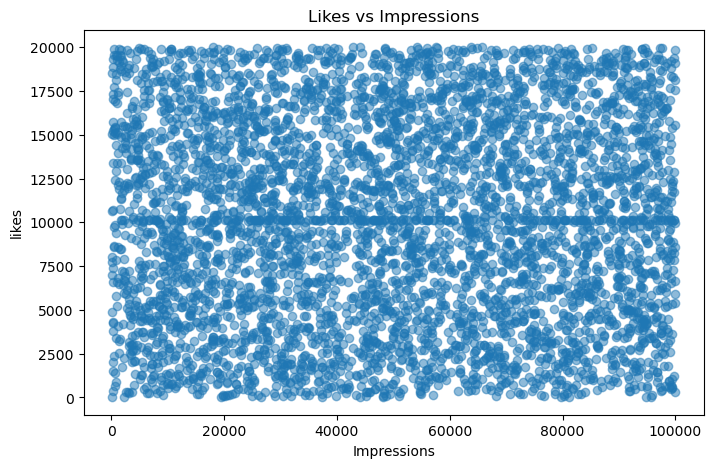

In [38]:
#Likes vs Impressions - Scatter
plt.figure(figsize=(8, 5))
plt.scatter(df['impression_count'],df['likes'],alpha=0.5)
plt.xlabel('Impressions')
plt.ylabel('likes')
plt.title('Likes vs Impressions')
plt.show()

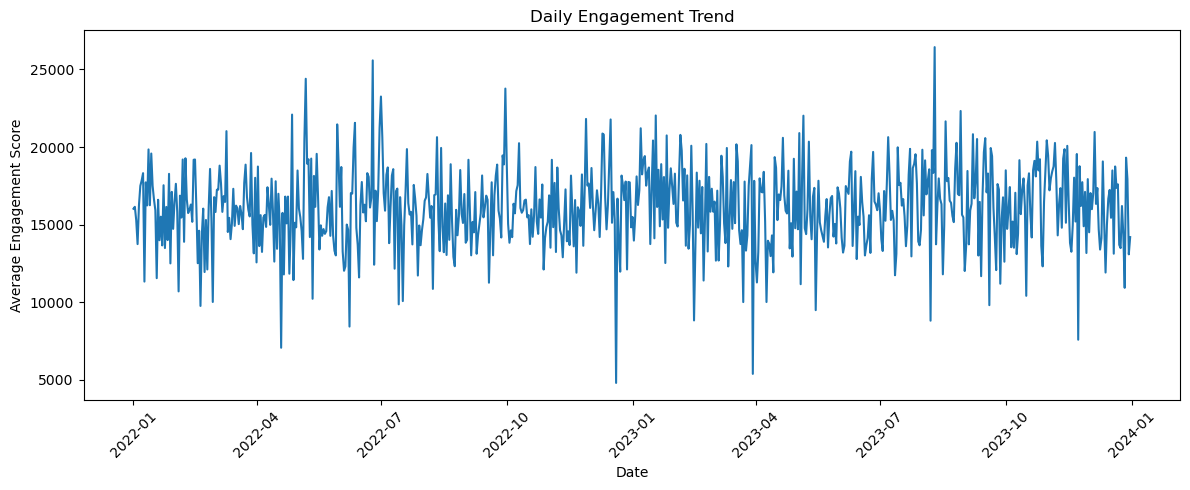

In [39]:
# Daily Engagement Trend
df['date'] = df['posted_at'].dt.date
daily_engagement = df.groupby('date')['engagement_score'].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_engagement.index,
    daily_engagement.values
)

plt.xlabel('Date')
plt.ylabel('Average Engagement Score')
plt.title('Daily Engagement Trend')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

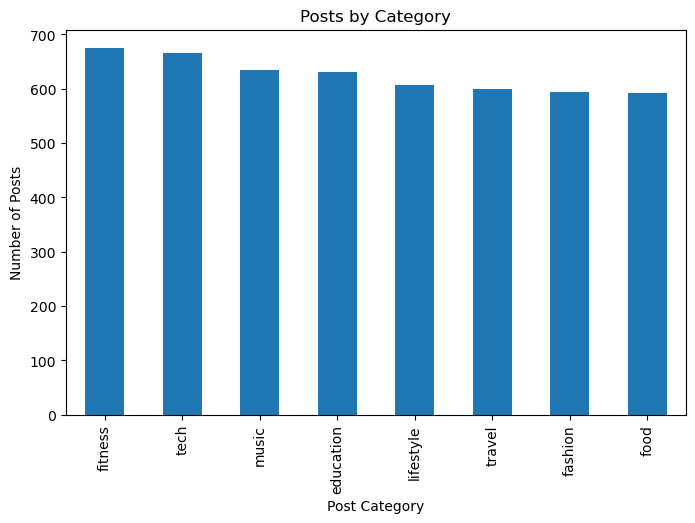

In [40]:
# Posts by Category
plt.figure(figsize=(8, 5))

df['post_category'].value_counts().plot(kind='bar')

plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')


plt.show()

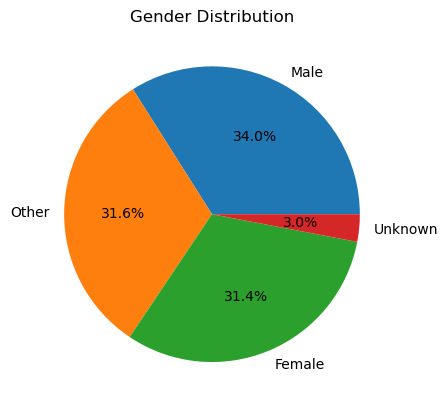

In [41]:
# Gender Distribution
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Gender Distribution')

plt.show()

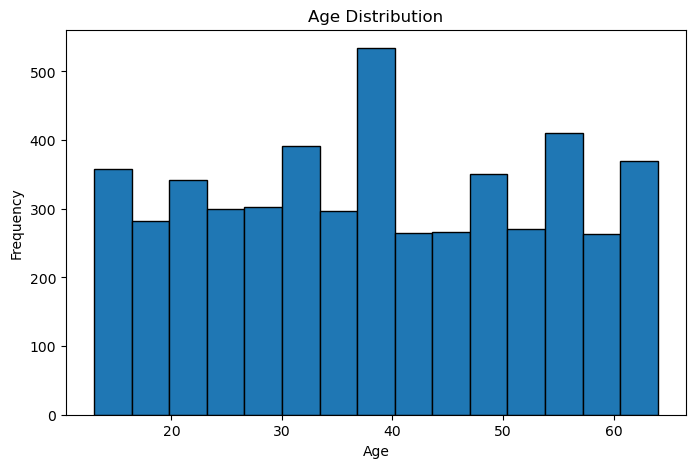

In [42]:
# Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(
    df['age'].dropna(),
    bins=15,
    edgecolor='black'
)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

plt.show()

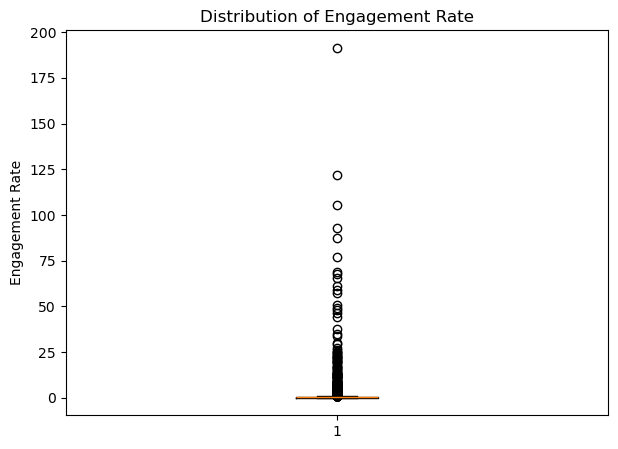

In [43]:
# Engagement Rate Box Plot
plt.figure(figsize=(7, 5))

plt.boxplot(
    df['engagement_rate'].dropna()
)

plt.ylabel('Engagement Rate')
plt.title('Distribution of Engagement Rate')

plt.show()

### Seaborn

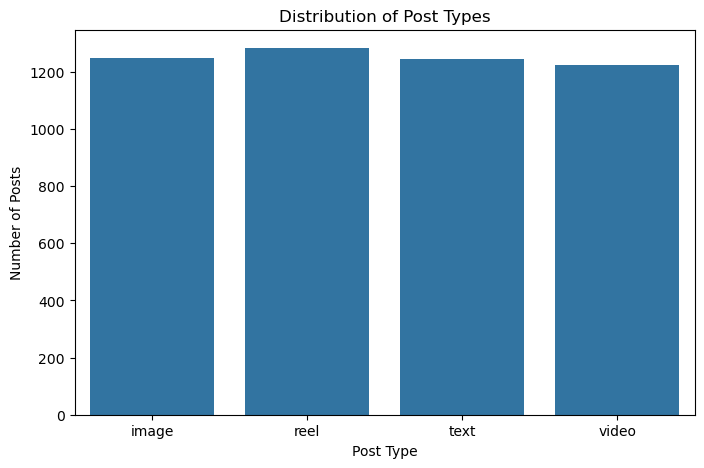

In [44]:
# Post Type Count Plot
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='post_type'
)

plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.title('Distribution of Post Types')

plt.show()

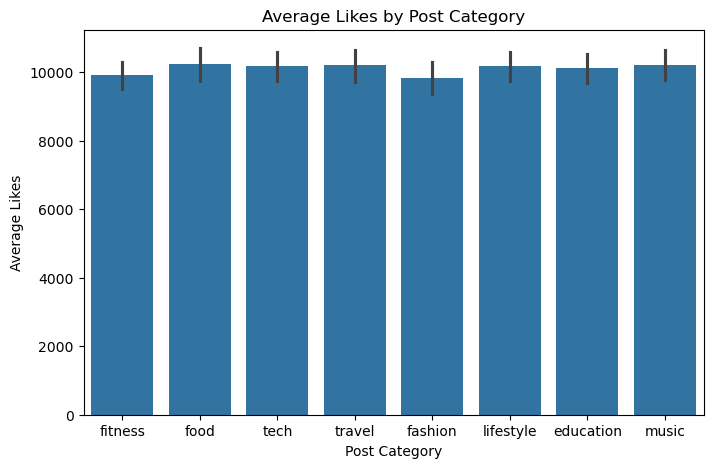

In [45]:
# Average Likes by Category
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='post_category',
    y='likes',
    estimator='mean'
)

plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.title('Average Likes by Post Category')

plt.show()

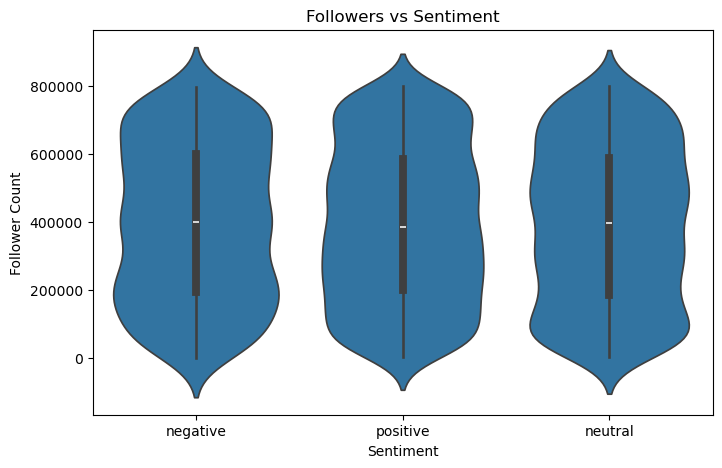

In [46]:
### Followers vs Sentiment
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x='sentiment',
    y='follower_count'
)

plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.title('Followers vs Sentiment')

plt.show()

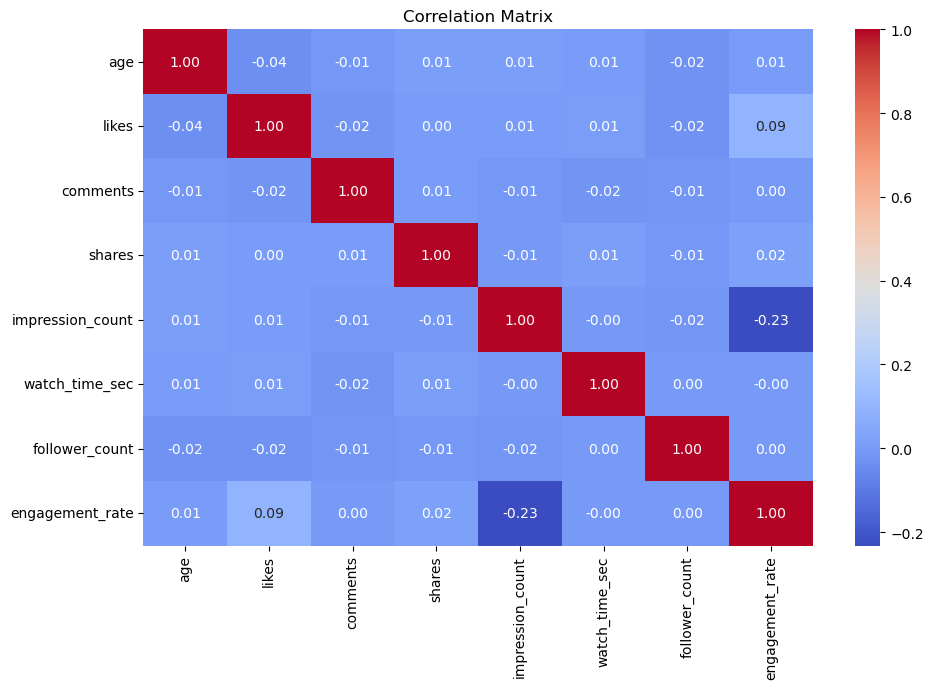

In [47]:
## Correlation Matrix
numeric_features = [
    'age',
    'likes',
    'comments',
    'shares',
    'impression_count',
    'watch_time_sec',
    'follower_count',
    'engagement_rate'
]

correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [48]:
plotly_data = df.groupby('post_type', as_index=False)['engagement_rate'].mean()

fig = px.bar(
    plotly_data,
    x='post_type',
    y='engagement_rate',
    title='Average Engagement Rate by Post Type',
    labels={
        'post_type': 'Post Type',
        'engagement_rate': 'Average Engagement Rate'
    }
)

fig.show()

## Analysis


#### 1. Content Performance

In [49]:
# Which post types have highest engagement? 
best_post_type = summary_by_post_type['engagement_score'].idxmax()

print("Best-performing post type:", best_post_type)
print(
    "Average engagement score:",
    summary_by_post_type.loc[
        best_post_type,
        'engagement_score'
    ]
)

Best-performing post type: image
Average engagement score: 16213.19246190858


In [50]:
# Best-performing content category?
category_analysis = df.groupby('post_category').agg(
    average_likes=('likes', 'mean'),
    average_comments=('comments', 'mean'),
    average_shares=('shares', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean')
).sort_values('average_likes', ascending=False)

category_analysis

,average_likes,average_comments,average_shares,average_engagement_rate
post_category,,,,
food,10225.502530,1510.876897,1002.801012,1.358628
music,10205.737008,1558.710236,1024.089764,0.888803
travel,10196.290000,1485.948333,968.306667,0.702223
lifestyle,10180.537068,1467.840198,991.140033,1.091019
tech,10171.560902,1505.548872,1009.369925,1.160475
education,10126.472266,1455.337559,996.445325,0.844222
fitness,9914.591111,1501.142222,1042.047407,0.865628
fashion,9843.341751,1530.540404,982.523569,0.807109


In [51]:
best_category = category_analysis.index[0]

print("Best-performing category:", best_category)
print(
    "Average likes:",
    category_analysis.loc[
        best_category,
        'average_likes'
    ]
)

Best-performing category: food
Average likes: 10225.50252951096


In [52]:
# Which countries have highest avg engagement rate?  
summary_by_country = df.groupby('country')[[
    'likes',
    'comments',
    'shares',
    'impression_count',
    'engagement_rate'
]].mean().sort_values(
    'engagement_rate',
    ascending=False
)

summary_by_country

,likes,comments,shares,impression_count,engagement_rate
country,,,,,
Brazil,9886.678571,1490.434524,1008.859127,49193.174603,1.540704
Australia,10294.107505,1485.803245,1029.693712,48346.383367,1.324339
France,10372.862903,1478.695565,1051.812500,51727.673387,1.146402
UAE,10227.473161,1541.214712,989.075547,48928.413519,1.112352
Canada,10063.054581,1546.582846,996.245614,48703.150097,0.916659
UK,9935.636917,1463.042596,985.681542,51119.393509,0.850966
Japan,10088.851695,1530.434322,959.351695,49616.135593,0.769623
Germany,10130.434694,1531.826531,973.379592,48605.406122,0.759000
India,9962.444860,1494.917757,1035.315888,52462.386916,0.655005


In [53]:
best_country = summary_by_country['engagement_rate'].idxmax()

print("Country with highest average engagement rate:", best_country)
print(
    "Average engagement rate:",
    summary_by_country.loc[
        best_country,
        'engagement_rate'
    ]
)

Country with highest average engagement rate: Brazil
Average engagement rate: 1.5407037970277777


### User Trends

In [54]:
# How age affects engagement?
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=['Below 18', '18-25', '26-35', '36-45', '46-55', 'Above 55']
)

age_analysis = df.groupby(
    'age_group',
    observed=True
)['engagement_rate'].mean().sort_values(ascending=False)

print("Average engagement rate by age group:")
print(age_analysis)

Average engagement rate by age group:
age_group
46-55       1.414058
18-25       1.059536
Below 18    0.867038
26-35       0.865316
36-45       0.860741
Above 55    0.709213
Name: engagement_rate, dtype: float64


In [55]:
best_age_group = age_analysis.index[0]

print("Age group with highest engagement:", best_age_group)
print(
    "Average engagement rate:",
    age_analysis.iloc[0]
)

Age group with highest engagement: 46-55
Average engagement rate: 1.4140579981936887


In [56]:
# Performance difference for verified accounts 
verified_analysis = df.groupby('is_verified')['engagement_rate'].mean().sort_values(ascending=False)

print("Average engagement rate by verification status:")
print(verified_analysis)

Average engagement rate by verification status:
is_verified
True     1.054250
False    0.954744
Name: engagement_rate, dtype: float64


In [57]:
best_verified_status = verified_analysis.index[0]

print("Best-performing account type:", best_verified_status)
print(
    "Average engagement rate:",
    verified_analysis.iloc[0]
)

Best-performing account type: True
Average engagement rate: 1.0542502229089028


### Behavioural insights

In [58]:
#Best time of day for impressions
print(df['posted_at'].head())
print(df['posted_at'].dt.hour.value_counts())

0   2022-12-17
1   2023-06-02
2   2023-05-07
3   2023-02-12
4   2023-05-23
Name: posted_at, dtype: datetime64[ns]
posted_at
0    5000
Name: count, dtype: int64


In [59]:
# Device type impact on watch time
device_analysis = df.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False)

print("Average watch time by device type:")
print(device_analysis)

Average watch time by device type:
device_type
mobile     4087.830760
tablet     3979.736429
desktop    3974.792521
Name: watch_time_sec, dtype: float64


In [60]:
best_device = device_analysis.index[0]

print("Device with highest average watch time:", best_device)
print(
    "Average watch time:",
    device_analysis.iloc[0],
    "seconds"
)

Device with highest average watch time: mobile
Average watch time: 4087.830760095012 seconds


In [61]:
# Which sentiment performs best?
sentiment_analysis = df.groupby('sentiment')['engagement_rate'].mean().sort_values(ascending=False)

print("Average engagement rate by sentiment:")
print(sentiment_analysis)

Average engagement rate by sentiment:
sentiment
negative    1.038486
neutral     0.991170
positive    0.919744
Name: engagement_rate, dtype: float64


In [62]:
best_sentiment = sentiment_analysis.index[0]

print("Best-performing sentiment:", best_sentiment)
print(
    "Average engagement rate:",
    sentiment_analysis.iloc[0]
)

Best-performing sentiment: negative
Average engagement rate: 1.0384856883375


In [63]:
# Behavior of negative/neutral sentiment posts
sentiment_comparison = df.groupby('sentiment').agg(
    average_likes=('likes', 'mean'),
    average_comments=('comments', 'mean'),
    average_shares=('shares', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean')
)

print(sentiment_comparison)

           average_likes  average_comments  average_shares  \
sentiment                                                    
negative    10208.081250       1516.094792     1007.307292   
neutral      9923.180092       1528.404060      996.565160   
positive    10180.046956       1480.650617     1005.086749   

           average_engagement_rate  
sentiment                           
negative                  1.038486  
neutral                   0.991170  
positive                  0.919744  
